In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import zipfile

with zipfile.ZipFile("dataset (1).zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
# Importing libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
dataset_path = "dataset/faces"

In [ ]:
images = []
labels = []

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (244, 244))
        images.append(img)
        labels.append(person)

In [ ]:
# Numpy Array
X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)

# print("Images:", X.shape)
# print("Labels:", y.shape)

In [ ]:
# Label Encoding
le = LabelEncoder()
y = le.fit_transform(y)
print(le.classes_)

['Aamir' 'Ajay' 'Akshay' 'Alia' 'Amitabh' 'Deepika' 'Disha' 'Farhan'
 'Ileana']


In [ ]:
# Train and Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42,stratify=y)

In [ ]:
# DATA AUgmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator()

In [ ]:
# Generators
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=16,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=16,
    shuffle=False
)

In [ ]:
#  CNN Model
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(244,244,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64,activation='relu'))
model.add(Dense(9, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 242, 242, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 121, 121, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 119, 119, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,947,273 (49.39 MB)

 Trainable params: 12,947,273 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(train_generator,validation_data=test_generator,epochs=30)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.1074 - loss: 2.2004 - val_accuracy: 0.2056 - val_loss: 2.1849
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.1296 - loss: 2.1846 - val_accuracy: 0.2778 - val_loss: 2.1390
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.2333 - loss: 2.0543 - val_accuracy: 0.2833 - val_loss: 2.0258
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.2519 - loss: 2.0154 - val_accuracy: 0.3500 - val_loss: 1.8284
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3185 - loss: 1.7770 - val_accuracy: 0.4056 - val_loss: 1.6611
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.3741 - loss: 1.7615 - val_accuracy: 0.3611 - val_loss: 1.6706
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3852 - loss: 1.6127 - val_accuracy: 0.4778 - val_loss: 1.5154
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.4296 - loss: 1.5400 - val_accuracy: 0.5056 - val_loss:

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 652ms/step - accuracy: 0.7278 - loss: 0.9023
Test Loss: 0.9023355841636658
Test Accuracy: 0.7277777791023254


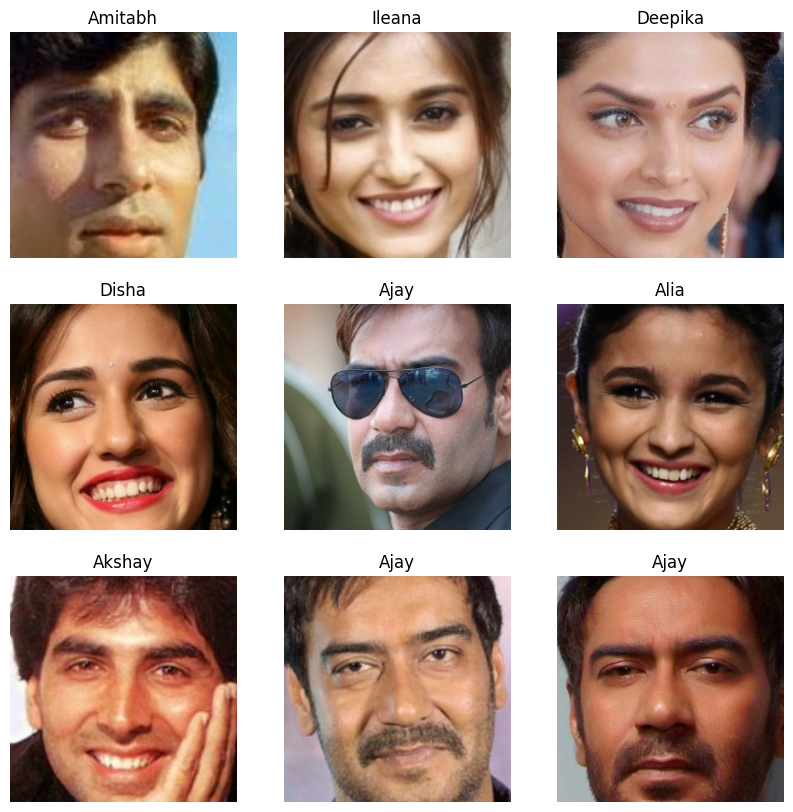

In [ ]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(le.inverse_transform([y_train[i]])[0])
    plt.axis("off")

plt.show()

In [ ]:
# PCA+ANN Model
# As data preprocessing is already completed we'll directly using the variables into our PCA model
# Flatten images for PCA
X_flat = X.reshape(X.shape[0], -1)

print(X_flat.shape)

(450, 178608)


In [ ]:
# Test and train
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_flat,y,test_size=0.4,random_state=42,stratify=y)

In [ ]:
# PCA MODEL
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_pca)
X_test_pca = pca.transform(X_test_pca)

print("Original Features :", X_flat.shape[1])
print("Reduced Features :", X_train_pca.shape[1])

Original Features : 178608
Reduced Features : 69


In [ ]:
#Encoded
from tensorflow.keras.utils import to_categorical

num_classes = len(le.classes_)

y_train_ann = to_categorical(y_train_pca, num_classes)
y_test_ann = to_categorical(y_test_pca, num_classes)

In [ ]:
#  PCA model
model_ann = Sequential([

    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')

])

model_ann.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,657 (233.04 KB)

 Trainable params: 59,657 (233.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile
model_ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Train
history_ann = model_ann.fit(X_train_pca,y_train_ann, validation_data=(X_test_pca, y_test_ann), epochs=30, batch_size=16)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.1333 - loss: 6.6123 - val_accuracy: 0.1833 - val_loss: 2.9706
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2185 - loss: 4.2807 - val_accuracy: 0.3111 - val_loss: 2.0978
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2556 - loss: 3.5868 - val_accuracy: 0.3667 - val_loss: 1.7922
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2630 - loss: 2.7505 - val_accuracy: 0.4111 - val_loss: 1.6599
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3667 - loss: 2.4146 - val_accuracy: 0.4333 - val_loss: 1.5477
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3630 - loss: 2.1496 - val_accuracy: 0.4444 - val_loss: 1.5153
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3889 - loss: 1.9266 - val_accuracy: 0.4500 - val_loss: 1.5015
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4704 - loss: 1.7486 - val_accuracy: 0.4500 - val_

In [ ]:
# PCA evaluation
loss, accuracy = model_ann.evaluate(X_test_pca,y_test_ann)

print("Test Accuracy :", accuracy)
print("Test Loss :", loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5889 - loss: 1.2524
Test Accuracy : 0.5888888835906982
Test Loss : 1.2524456977844238


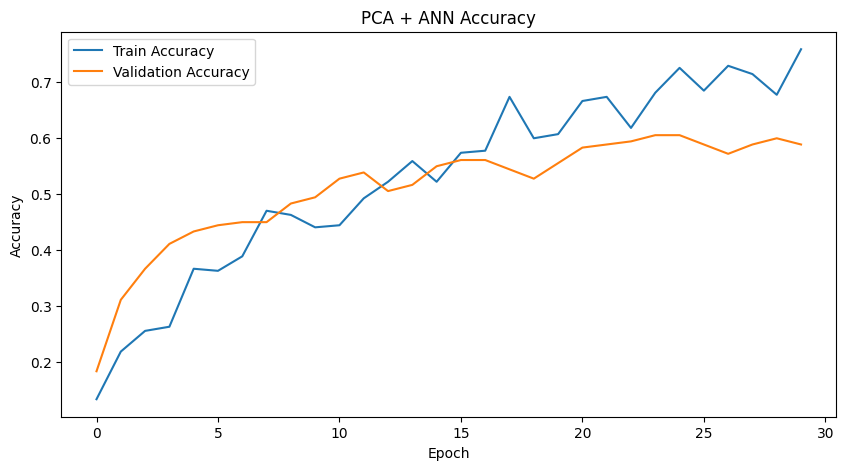

In [ ]:
# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PCA + ANN Accuracy")

plt.legend()
plt.show()

In [ ]:
predictions = model_ann.predict(X_test_pca)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_ann, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


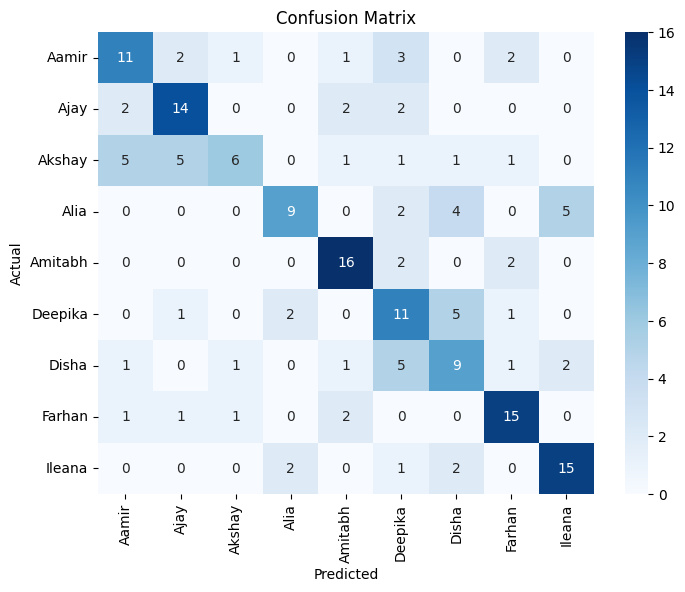

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Saving
model_ann.save("PCA_ANN_Model.keras")


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Test Accuracy","Test Loss","Epochs","Dataset","Input","Feature Extraction","Classifier"
    ],
    "Custom CNN": ["72.78%","0.9023",30,"450 Images (9 Classes)","224×224×3 RGB Images","Automatic (CNN)","Softmax"
    ],
    "PCA + ANN": ["58.89%","1.2524",30,"450 Images (9 Classes)","PCA Features","Principal Component Analysis","Artificial Neural Network"]
})

comparison

,Metric,Custom CNN,PCA + ANN
0,Test Accuracy,72.78%,58.89%
1,Test Loss,0.9023,1.2524
2,Epochs,30,30
3,Dataset,450 Images (9 Classes),450 Images (9 Classes)
4,Input,224×224×3 RGB Images,PCA Features
5,Feature Extraction,Automatic (CNN),Principal Component Analysis
6,Classifier,Softmax,Artificial Neural Network


In [ ]:
model.save("cnn_face_recognition.keras")

In [ ]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
from google.colab import files

files.download("cnn_face_recognition.keras")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>